Epoch 1/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 104s 456ms/step - accuracy: 0.2470 - loss: 2.1463 - val_accuracy: 0.3400 - val_loss: 1.8752
Epoch 2/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 85s 452ms/step - accuracy: 0.4770 - loss: 1.5990 - val_accuracy: 0.5380 - val_loss: 1.3949
Epoch 3/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 80s 425ms/step - accuracy: 0.5980 - loss: 1.2942 - val_accuracy: 0.6260 - val_loss: 1.1237


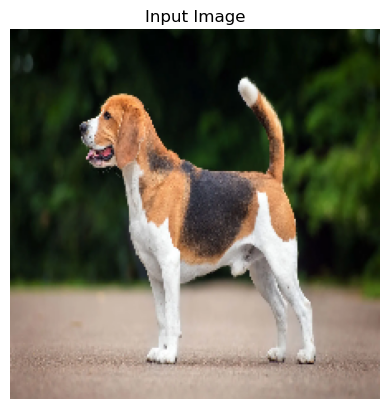

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted Class: dog


In [8]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train[:3000]
y_train = y_train[:3000]
x_test = x_test[:500]
y_test = y_test[:500]
x_train = np.array([cv2.resize(img, (224,224)) for img in x_train])
x_test = np.array([cv2.resize(img, (224,224)) for img in x_test])

# Preprocess
x_train = preprocess_input(x_train)
x_test = preprocess_input(x_test)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

for layer in base_model.layers[-20:]:
    layer.trainable = True

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    x_train, y_train,
    epochs=3,   # 🔥 reduced from 10 → 3
    batch_size=16,
    validation_data=(x_test, y_test)
)

class_names = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]

img = cv2.imread("test.jpg")
if img is None:
    print("❌ Image not found")
else:
    img = cv2.resize(img, (224,224))

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Input Image")
    plt.axis('off')
    plt.show()
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)
    prediction = model.predict(img)
    class_index = np.argmax(prediction)

    print("Predicted Class:", class_names[class_index])